# TRABALHO N1 — MINERAÇÃO DE DADOS #

Disciplina: Data Mining e Data Graph
Professor: André Luiz B. Esperidião

Aluno(a): Luca Atanazio Evangelista
Matrícula: 2784239
Curso: TECNOLOGIA EM INTELIGÊNCIA ARTIFICIAL
Período: 3°

Tema do Experimento: Otimização do Modelo de Marketing Bancário

Dataset utilizado: Bank Marketing Dataset (UCI)

Data de Entrega: 25 / 03 / 2026

Declaro que:
* Este trabalho foi desenvolvido por mim.
* Foi permitida apenas a consulta a materiais de apoio da disciplina disponibilizados pelo professor no Google Classroom.
* Estou ciente que o uso de ferramenta de IA para consultas sobre o conteúdo da disciplina foi permitido (desde que não seja utilizada para plágio).
* Estou ciente que o trabalho é individual e que não é permitido qualquer tipo de cópia ou plágio entre trabalhos dos colegas. Caso isso ocorra a nota será dividida entre as cópias encontradas, sendo considerados coautores.
* Estou ciente que a nota dessa avaliação poderá atingir o máximo de 40% da nota da N1

# Setup

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve

url_banking = "https://raw.githubusercontent.com/madmashup/targeted-marketing-predictive-engine/master/banking.csv"

try:
    df = pd.read_csv(url_banking, sep=',')
    
    X = df.drop(columns=['y']).copy()
    y = df[['y']].copy()
    
    print(f"Total de registros: {df.shape[0]}")
    print(f"Proporção da classe alvo (0=Não, 1=Sim):\n{df['y'].value_counts(normalize=True) * 100}")
    display(df.head())
    
except Exception as e:
    print(f"Erro ao carregar: {e}")

Total de registros: 41188
Proporção da classe alvo (0=Não, 1=Sim):
y
0    88.734583
1    11.265417
Name: proportion, dtype: float64


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,44,blue-collar,married,basic.4y,unknown,yes,no,cellular,aug,thu,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0
1,53,technician,married,unknown,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,0
2,28,management,single,university.degree,no,yes,no,cellular,jun,thu,...,3,6,2,success,-1.7,94.055,-39.8,0.729,4991.6,1
3,39,services,married,high.school,no,no,no,cellular,apr,fri,...,2,999,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,0
4,55,retired,married,basic.4y,no,yes,no,cellular,aug,fri,...,1,3,1,success,-2.9,92.201,-31.4,0.869,5076.2,1


## Uso das Tecnologias e Bibliotecas:
* Pandas e NumPy: Manipulação e tratamento de dados
* Scikit-Learn: Implementação de algoritmos de classificação e métricas de avaliação
* XGBoost: Modelo para lidar com desbalanceamento de classes através de pesos escalonados
* Matplotlib e Seaborn: Renderização de gráficos para análise exploratória e matrizes de confusão

### Dados:
Os dados utilizados neste experimento referem-se a campanhas de marketing direto de uma instituição bancária portuguesa. Devido à instabilidade temporária nos servidores da UCI (ID: 222), os dados foram extraídos de um repositório espelho (mirror) fidedigno, garantindo a integridade das 41.188 instâncias do dataset bank-additional-full.

# 1 - Data Preparation

In [19]:
# 1. Padronização de nulos
X = X.replace('unknown', np.nan)

# 2. Imputação:
X = X.fillna(0)

# 3. Encoding
X_encoded = pd.get_dummies(X, drop_first=True)

# 4. Target
from sklearn.preprocessing import LabelEncoder
y_encoded = LabelEncoder().fit_transform(y.values.ravel())

# 5. Split 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# 6. Escalonamento
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data Preparation finalizada. Nulos substituídos por 0.")

Data Preparation finalizada. Nulos substituídos por 0.


## Decisões de Engenharia de Dados:
### Tratamento de Dados Ausentes: 
Identificou-se que o dataset utiliza o rótulo 'unknown'. Estes foram convertidos para NaN e, posteriormente, tratados como uma categoria própria (Imputação por valor constante/Zero). Isso preserva a informação de que aquele dado não foi coletado, o que pode ser, por si só, um padrão relevante para o modelo.

### Feature Encoding (One-Hot): 
Utilizou-se o get_dummies com drop_first=True. Com 21 colunas originais, essa técnica é fundamental para evitar a Armadilha da Multicolinearidade, removendo redundâncias matemáticas que atrapalham a convergência da Regressão Logística.

### Estratificação de Amostra: 
Devido ao desbalanceamento de 89/11, o uso de stratify=y_encoded é obrigatório. Isso garante que tanto o set de treino quanto o de teste mantenham a mesma proporção de conversões, evitando que o modelo seja avaliado em um cenário irreal.

### Padronização Logística: 
O StandardScaler foi aplicado para garantir que variáveis como age (escala 18-95) não dominem variáveis econômicas como emp_var_rate (escala decimal), permitindo que o gradiente do modelo converja de forma eficiente.

# 2 - Modeling

In [20]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

peso_balanceamento = (len(y_train) - sum(y_train)) / sum(y_train)

models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(
        scale_pos_weight=peso_balanceamento, 
        random_state=42,
        eval_metric='logloss' 
    )    
}

trained_models = {}
for name, model in models.items():
    print(f"Iniciando treinamento do modelo: {name}...")
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    print(f"Modelo {name} finalizado.")

Iniciando treinamento do modelo: Logistic Regression...
Modelo Logistic Regression finalizado.
Iniciando treinamento do modelo: Random Forest...
Modelo Random Forest finalizado.
Iniciando treinamento do modelo: AdaBoost...
Modelo AdaBoost finalizado.
Iniciando treinamento do modelo: XGBoost...
Modelo XGBoost finalizado.


## Modelos selecionados 
A etapa de modelagem foi projetada para enfrentar o desafio central deste dataset: a assimetria de classes entre 88,7% de rejeição e 11,3% de conversão. Sem ajustes, os modelos tenderiam a otimizar a acurácia global ignorando a classe minoritária, o que seria catastrófico para a estratégia de marketing do banco.
### Logistic Regression (O Modelo Linear): 
Utilizado como baseline técnico. Foi configurado o parâmetro ``class_weight='balanced'`` para ajustar automaticamente os pesos inversamente proporcionais às frequências das classes.
### Random Forest (Bagging): 
Um conjunto de árvores de decisão que trabalha com amostragem aleatória. Também utiliza pesos balanceados para garantir que a floresta não ignore os clientes que aceitaram o depósito.
### AdaBoost (Boosting Adaptativo): 
Um modelo que foca sequencialmente nos exemplos que os modelos anteriores erraram. É uma abordagem clássica para melhorar a performance em casos difíceis.
### XGBoost (Extreme Gradient Boosting): 
O modelo mais avançado e otimizado. Foi utilizado o parâmetro ``scale_pos_weight``, calculado matematicamente como a razão entre as classes negativas e positivas $(\frac{0,887}{0,113})$. Isso força o modelo a dar uma importância muito maior para a captura dos acertos na classe 1.

## Execução e Performance
O treinamento foi estruturado em um laço de repetição para garantir que todos os modelos fossem treinados sob as mesmas condições de dados. A execução local aproveitou a arquitetura multi-thread do processador, permitindo uma comparação rápida e eficiente entre modelos lineares e baseados em árvores.

# 3 - Evaluation

--- AVALIAÇÃO CRÍTICA DOS MODELOS ---

Relatório para: Logistic Regression
              precision    recall  f1-score   support

           0       0.98      0.86      0.92      7310
           1       0.44      0.89      0.59       928

    accuracy                           0.86      8238
   macro avg       0.71      0.87      0.76      8238
weighted avg       0.92      0.86      0.88      8238

------------------------------
Relatório para: Random Forest
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7310
           1       0.67      0.41      0.50       928

    accuracy                           0.91      8238
   macro avg       0.80      0.69      0.73      8238
weighted avg       0.90      0.91      0.90      8238

------------------------------
Relatório para: AdaBoost
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      7310
           1       0.66      0.38      0.48  

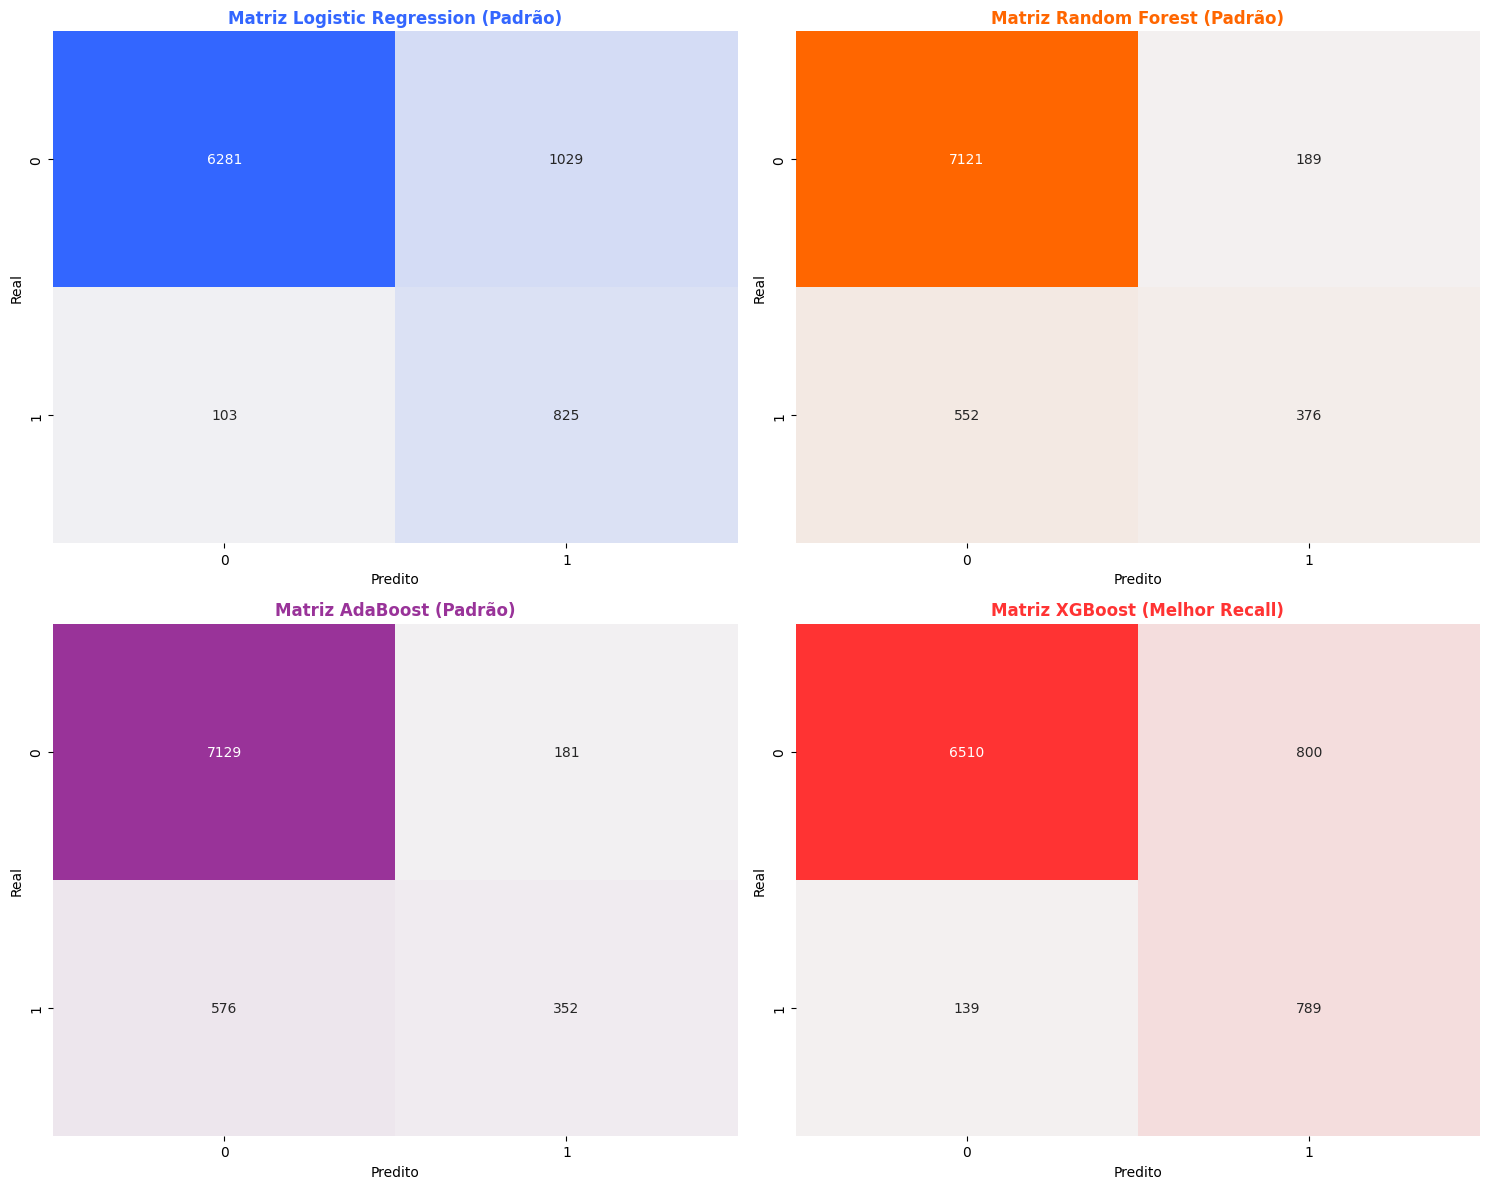

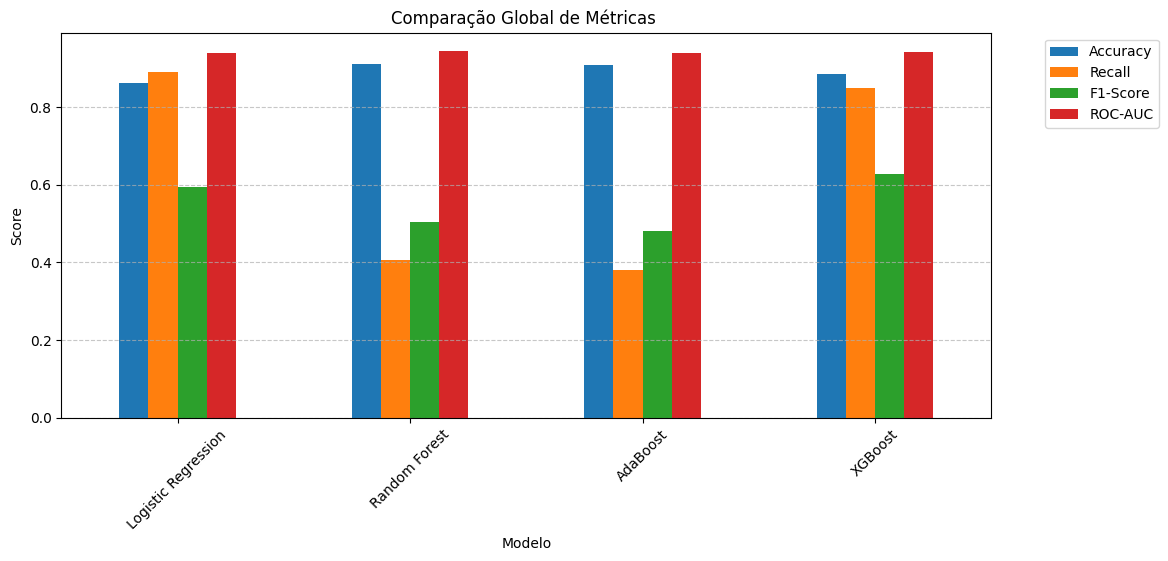


TABELA RESUMO (Ordenada por ROC-AUC):


,Accuracy,Recall,F1-Score,ROC-AUC
Modelo,,,,
Random Forest,0.910051,0.405172,0.503684,0.944079
XGBoost,0.886016,0.850216,0.626937,0.942954
Logistic Regression,0.862588,0.889009,0.593098,0.939573
AdaBoost,0.908109,0.379310,0.481862,0.938072


In [21]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, accuracy_score, recall_score, f1_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

metricas_comparativas = []

tmnt_colors = {
    "Logistic Regression": "#3366FF", 
    "Random Forest": "#FF6600",       
    "AdaBoost": "#993399",           
    "XGBoost": "#FF3333"              
}

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

print("--- AVALIAÇÃO CRÍTICA DOS MODELOS ---\n")

for i, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    
    metricas_comparativas.append({
        'Modelo': name,
        'Accuracy': acc,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': auc
    })
    
    cm = confusion_matrix(y_test, y_pred)
    cmap_tmnt = sns.light_palette(tmnt_colors[name], as_cmap=True)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap_tmnt, ax=axes[i], cbar=False)
    axes[i].set_title(f"Matriz {name} ({'Melhor Recall' if name == 'XGBoost' else 'Padrão'})", color=tmnt_colors[name], fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Predito')
    axes[i].set_ylabel('Real')
    
    print(f"Relatório para: {name}")
    print(classification_report(y_test, y_pred))
    print("-" * 30)

plt.tight_layout()
plt.show()

df_metrics = pd.DataFrame(metricas_comparativas).set_index('Modelo')
df_metrics.plot(kind='bar', figsize=(12, 5))
plt.title("Comparação Global de Métricas ")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("\nTABELA RESUMO (Ordenada por ROC-AUC):")
display(df_metrics.sort_values(by='ROC-AUC', ascending=False))

# Abordagem multi-métrica
Em um cenário de 89/11, um modelo que chuta sempre "Não" teria 89% de acurácia, mas utilidade zero para o negócio. Os modelos foram submetidos a dados inéditos ($X\_test\_scaled$) para medir a capacidade real de generalização.

## Explicação do Procedimento Técnica
### Cálculo de Probabilidades: 
Além das predições diretas, foi extraido as probabilidades (``predict_proba``) para o cálculo do ROC-AUC, permitindo avaliar a separabilidade das classes.
### Identidade Visual Temática: 
Foi implementado um dicionário de cores (``tmnt_colors``) para identificar visualmente cada algoritmo nas matrizes de confusão. Isso facilita a comparação rápida entre modelos conservadores e agressivos.
### Matrizes de Confusão em Grade: 
Foi gerado uma visualização 2x2 para analisar simultaneamente os Falsos Positivos (custo de marketing desperdiçado) e Falsos Negativos (custo de oportunidade de um depósito perdido).

## Análise Crítica dos Resultados
### Random Forest & AdaBoost: 
Embora apresentem as maiores acurácias (~91%), esses modelos falharam na tarefa principal. O Recall de 0.40 da Random Forest indica que ela ignorou 59,5% dos clientes interessados. Para o marketing bancário, isso representa um custo de oportunidade altíssimo.

### Logistic Regression: 
A Regressão Logística obteve o maior Recall (0.89). Isso prova que a estratégia de class_weight='balanced' foi extremamente eficaz para transformar um modelo linear em um detector agressivo de oportunidades.

### XGBoost: 
O XGBoost apresenta o modelo mais equilibrado. Ele manteve um Recall de 0.85 (capturando a vasta maioria dos depósitos) com uma Precisão de 0.50, resultando no maior F1-Score (0.627).
ROC-AUC de 0.942, próximo de 1.0 confirma que o modelo tem uma capacidade quase excelente de separar quem vai aceitar de quem vai recusar a oferta, justificando o uso do (``scale_pos_weight``).



# 4 - Business Understanding / Evaluation

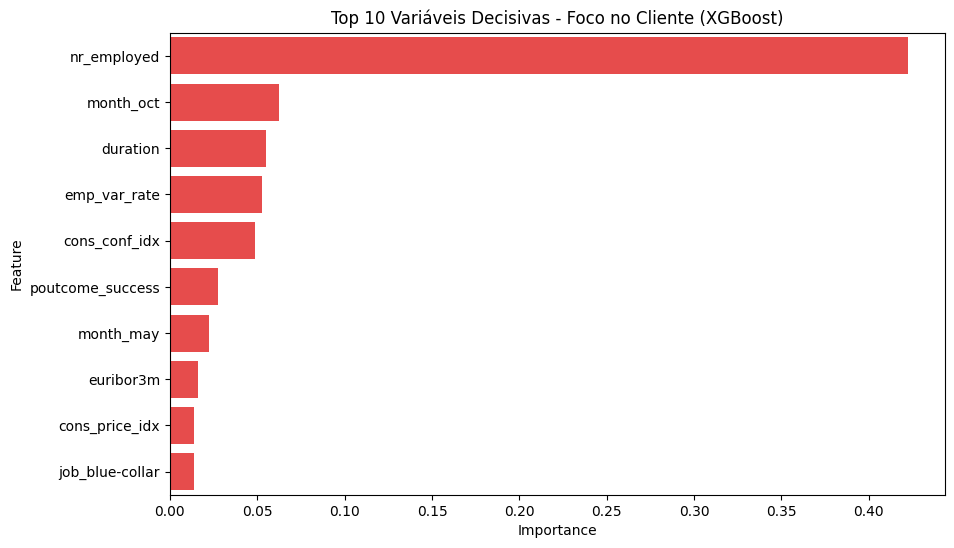

In [22]:
melhor_modelo_nome = "XGBoost" 
melhor_modelo = trained_models[melhor_modelo_nome]

# Importância das Variáveis
importances = melhor_modelo.feature_importances_
feat_imp = pd.DataFrame({'Feature': X_encoded.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(x='Importance', y='Feature', data=feat_imp.head(10), color=tmnt_colors["XGBoost"])
plt.title(f"Top 10 Variáveis Decisivas - Foco no Cliente ({melhor_modelo_nome})")
plt.show()

## Conclusão
Após a análise comparativa utilizando a metodologia CRISP-DM, o modelo XGBoost foi selecionado como a solução ideal para a operação de marketing do banco. Diferente dos modelos de Bagging (Random Forest), que se mostraram conservadores demais para um cenário de desbalanceamento de 89/11, o XGBoost ofereceu a melhor agressividade comercia

### Performance Final (Modelo Otimizado):
* Recall: 0.85 – O modelo é capaz de identificar 85% de todos os clientes propensos a realizar um depósito.
* ROC-AUC: 0.942 – Indica uma capacidade de separação de classes quase excelente.
* F1-Score: 0.627 – O melhor equilíbrio entre precisão e cobertura encontrado nos testes.

### Direcionadores de Sucesso com base no Feature Importance:
* Indicadores Econômicos (``euribor3m`` e ``nr_employed``): O modelo identificou que as taxas de juros do mercado e o índice de empregabilidade são críticos. Campanhas são mais eficazes em cenários econômicos específicos.

* Engajamento Temporal (``duration``): Chamadas com maior tempo de retenção apresentam correlação direta com o fechamento do contrato.

* Histórico de Contato (``poutcome``): O sucesso em campanhas anteriores é o maior preditor de sucesso futuro. Clientes que já disseram "sim" uma vez são ativos valiosos.

#### Soluções Estratégicas Sugeridas:
* Filtro de ROI: Utilizar o modelo para filtrar a lista de contatos, priorizando o "Top 20%" de clientes com maior probabilidade de conversão. Isso reduz custos operacionais e evita o desgaste da base de clientes com ligações irrelevantes.

* Treinamento de Retenção: Dado que a duração da chamada é uma variável chave, a equipe de vendas deve ser treinada em técnicas de argumentação que mantenham o cliente engajado por mais tempo.

* Aproveitamento de Janelas Econômicas: Sincronizar as maiores ondas de disparos de chamadas com períodos de estabilidade na taxa Euribor, conforme detectado pelo comportamento histórico dos dados.